1


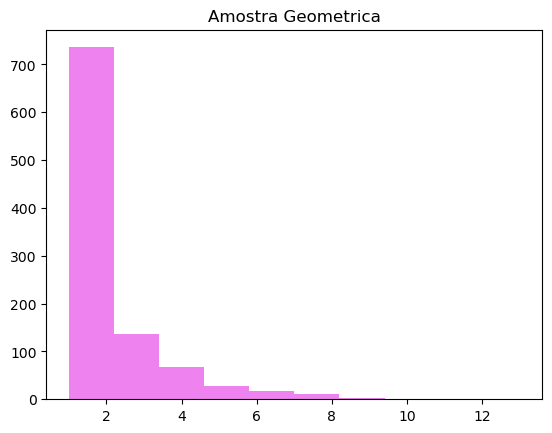

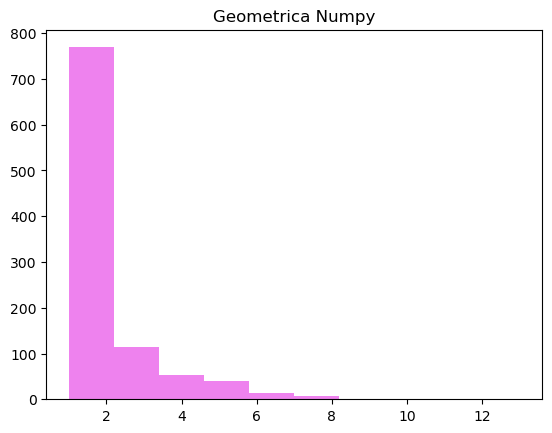

In [4]:
#exercicio 1

import numpy as np
import matplotlib.pyplot as plt


X = 1
p = 0.5

# Método ingenuo unico
bernoulli = np.random.uniform() < p

while bernoulli != 1:
    bernoulli = np.random.uniform( ) < p
    X +=1

M = 1000
amostra = []

# Método ingenuo para amostras maiores
for i in range(M):
    X = 1
    p = 0.5
    bernoulli = np.random.uniform() < p 

    while bernoulli != 1:
        bernoulli = np.random.uniform( ) < p
        X +=1
    amostra.append(X)
print(X)

# Plotagem dos gráficos
histograma_amostra = plt.hist(amostra, color="violet")
plt.title("Amostra Geometrica")
plt.show(histograma_amostra)

geometrica = np.random.geometric(p=0.5, size=M)

histograma_geo = plt.hist(geometrica, color="violet")
plt.title("Geometrica Numpy")
plt.show(histograma_geo)

Comparando os gráficos:

Como podemos notar a semelhança nos gráficos, a lógica do método ingênuo segue fielmente o processo da distribuição geométrica, sendo estatisticamente equivalente ao gerado pelo do NumPy.

Se variarmos o p sendo maior, a chance de sucesso é quase que imediata, fazendo com que a cauda à direita do gráfico fique muito mais curta.
O oposto acontece quando o p fica menor.

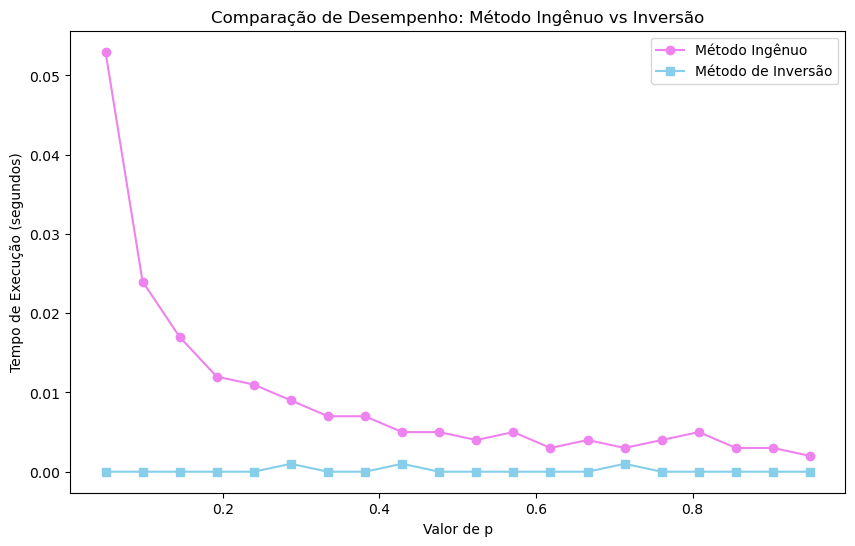

In [2]:
#exercicio 2

import time

# Parâmetros iniciais
M = 1000
valores_p = np.linspace(0.05, 0.95, 20) 

tempos_ingenuo = []
tempos_inversao = []


for p in valores_p:
    # Cronometrando o tempo ingenuo.
    inicio_ingenuo = time.time()
    amostra_ingenuo = []
    for i in range(M):
        x = 1
        while np.random.uniform() >= p:
            x += 1
        amostra_ingenuo.append(x)
    fim_ingenuo = time.time()
    tempos_ingenuo.append(fim_ingenuo - inicio_ingenuo)
    
    # Cronometrando o Método de Inversão
    inicio_inversao = time.time()
    
    U = np.random.uniform(size=M)
    amostra_inversao = np.ceil(np.log(U) / np.log(1 - p))
    
    fim_inversao = time.time()
    tempos_inversao.append(fim_inversao - inicio_inversao)

# Gráfico Comparativo
plt.figure(figsize=(10, 6))
plt.plot(valores_p, tempos_ingenuo, label="Método Ingênuo", marker='o', color='violet')
plt.plot(valores_p, tempos_inversao, label="Método de Inversão", marker='s', color='skyblue')

plt.title("Comparação de Desempenho: Método Ingênuo vs Inversão")
plt.xlabel("Valor de p")
plt.ylabel("Tempo de Execução (segundos)")
plt.legend()
plt.show()

O gráfico comprova que o método de inversão é infinitamente superior em estabilidade e eficiência computacional. 
Já o método ingênuo é ineficiente e deve ser evitado na simulação de eventos com p muito baixo, devido ao alto custo de processamento.  

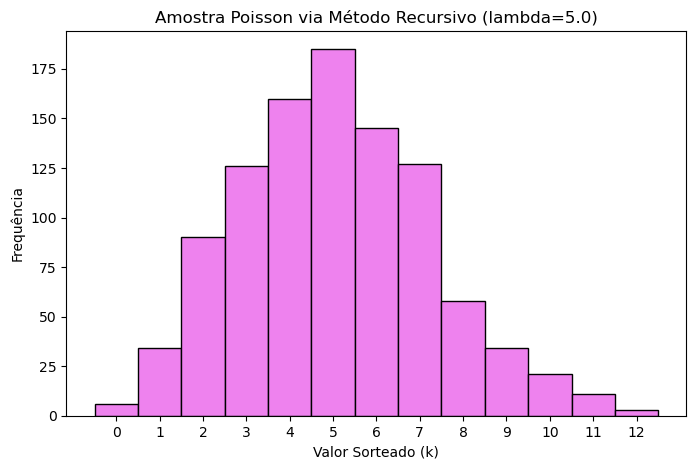

In [3]:
# Exercicio 3

# Parâmetros
M = 1000
Lambda = 5.0
amostra_poisson = []

# Método Recursivo
for _ in range(M):
    U = np.random.uniform()
    k = 0
    p = np.exp(-Lambda)
    F = p

    while U > F:
        k += 1
        p = p * (Lambda / k)
        F += p
        
    amostra_poisson.append(k)

# Plotando o histograma
plt.figure(figsize=(8, 5))
plt.hist(amostra_poisson, bins=range(0, max(amostra_poisson) + 2), color="violet", edgecolor='black', align='left')
plt.title(f"Amostra Poisson via Método Recursivo (lambda={Lambda})")
plt.xlabel("Valor Sorteado (k)")
plt.ylabel("Frequência")
plt.xticks(range(0, max(amostra_poisson) + 1))
plt.show()